In [3]:
from inference_sdk import InferenceHTTPClient
from inference_sdk import InferenceConfiguration

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key="wicm1z8DluTpwmaekcAG"
)



result = CLIENT.infer(
    r"C:\Users\lolen\Downloads\Jupyter Mac\Python\5-Projects\Roboflow Football\download (1).png", 
    model_id="football-players-detection-3zvbc/12"
)

ModuleNotFoundError: No module named 'dataclasses_json'

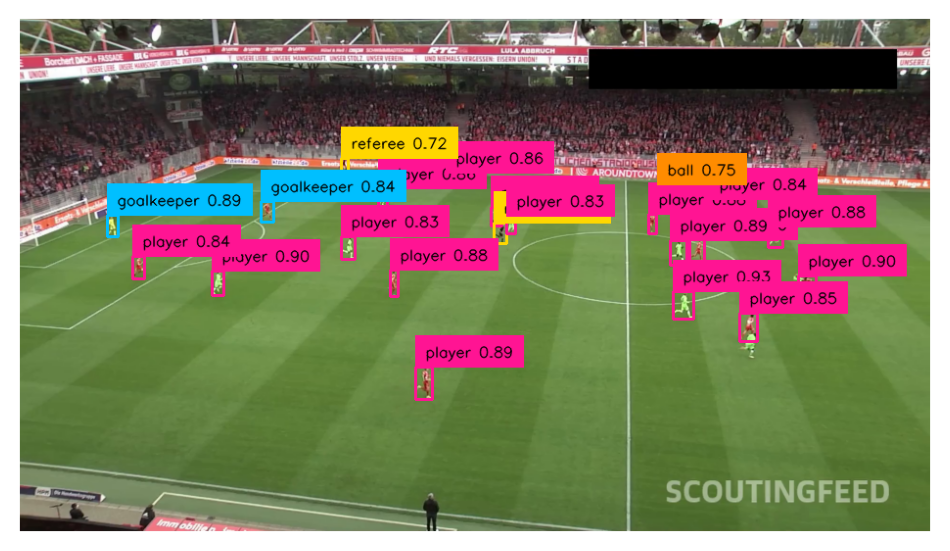

In [ ]:
import supervision as sv
import cv2
detections = sv.Detections.from_inference(result)


RESULT_IMAGE_PATH = "/output_image.jpg"

box_annotator = sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000')
)

labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections['class_name'], detections.confidence)
]


# Load image
image = cv2.imread(r"C:\Users\lolen\Downloads\Jupyter Mac\Python\5-Projects\Roboflow Football\download (1).png")

annotated_frame = image.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections,
    labels=labels)


sv.plot_image(annotated_frame)

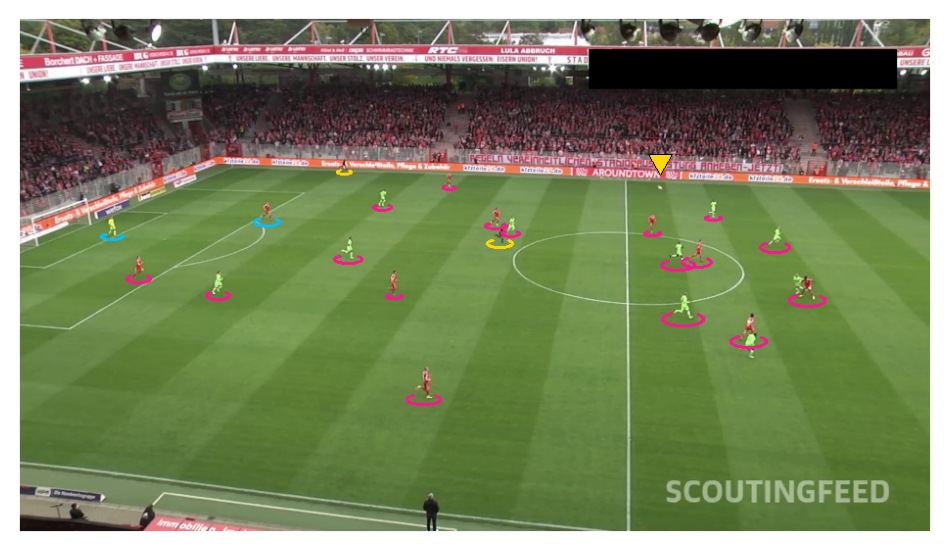

In [19]:
import supervision as sv
import cv2


detections = sv.Detections.from_inference(result)


RESULT_IMAGE_PATH = "/output_image.jpg"
BALL_ID = 0

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER,text_scale=0.2,  # Adjusts text size (increase for larger text)
    text_thickness=1  # Adjusts text boldness
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)


tracker = sv.ByteTrack()
tracker.reset()

# Load image
frame = cv2.imread(r"C:\Users\lolen\Downloads\Jupyter Mac\Python\5-Projects\Roboflow Football\download (1).png")


ball_detections = detections[detections.class_id == BALL_ID]
ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

all_detections = detections[detections.class_id != BALL_ID]
all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
all_detections.class_id -= 1
all_detections = tracker.update_with_detections(detections=all_detections)

labels = [
    f"#{tracker_id}"
    for tracker_id
    in all_detections.tracker_id
]

annotated_frame = frame.copy()
annotated_frame = ellipse_annotator.annotate(
    scene=annotated_frame,
    detections=all_detections)
# annotated_frame = label_annotator.annotate(
#     scene=annotated_frame,
#     detections=all_detections,
#     labels=labels)
annotated_frame = triangle_annotator.annotate(
    scene=annotated_frame,
    detections=ball_detections)

sv.plot_image(annotated_frame)

In [21]:
import supervision as sv
from tqdm import tqdm

RESULT_VIDEO_PATH = "121364_0_result.mp4"
SOURCE_VIDEO_PATH = r"C:\Users\lolen\Downloads\Jupyter Mac\Python\5-Projects\Roboflow Football\121364_0.mp4"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(RESULT_VIDEO_PATH, video_info=video_info)

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)
label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER,
    text_scale=0.2,  # Adjusts text size
    text_thickness=1  # Adjusts text boldness
)
triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

with video_sink:
    for frame_id, frame, prediction in tqdm(
        CLIENT.infer_on_stream(SOURCE_VIDEO_PATH, model_id="soccer-players-5fuqs/1")
    ):
        detections = sv.Detections.from_inference(prediction)

        ball_detections = detections[detections.class_id == BALL_ID]
        ball_detections.xyxy = sv.pad_boxes(xyxy=ball_detections.xyxy, px=10)

        all_detections = detections[detections.class_id != BALL_ID]
        all_detections = all_detections.with_nms(threshold=0.5, class_agnostic=True)
        all_detections.class_id -= 1
        all_detections = tracker.update_with_detections(detections=all_detections)

        labels = [f"#{tracker_id}" for tracker_id in all_detections.tracker_id]

        annotated_frame = frame.copy()
        annotated_frame = ellipse_annotator.annotate(
            scene=annotated_frame,
            detections=all_detections
        )
        annotated_frame = triangle_annotator.annotate(
            scene=annotated_frame,
            detections=ball_detections
        )

        video_sink.write_frame(annotated_frame)

print(f"Annotated video saved at {RESULT_VIDEO_PATH}")


750it [10:09,  1.23it/s]

Annotated video saved at 121364_0_result.mp4
